In [11]:
import torch
import random
from torch.utils.data import Dataset, DataLoader
import chess
import chess.svg
from IPython.display import display, SVG
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
import pyarrow as pa 
import pyarrow.parquet as pq

In [12]:
import sys
import os

module_path = os.path.abspath(os.path.join('..', 'libraries','c', 'chessintionlib'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Ahora ya puedes importar tu función
from chess_aux_c import uci_to_number, number_to_uci, concat_fen_legal, concat_fen_legal_bits, concat_fen_legal_ptr, normalize_perspective, translate_move_to_real

In [3]:
def read_data(file,page,size):
    with pq.ParquetFile(file) as pf:
        print("reading",file, page, size, pf.metadata)
    
        iterb = pf.iter_batches(batch_size = size)
        for i in range(page):
            next(iterb)
        
        batches = next(iterb)

        df_chess = pa.Table.from_batches([batches]).to_pandas()
        
        batches = None
        iterb = None
        
        # reshape
        df_chess['board'] = df_chess['board'].apply(lambda board: board.reshape(77, 8, 8).astype(int))
        df_chess.info(memory_usage='deep')
        df_chess.memory_usage(deep=True)
        return df_chess

reading lc0_converted.parquet.gzip 0 300 <pyarrow._parquet.FileMetaData object at 0x77b0a00c1c60>
  created_by: parquet-cpp-arrow version 14.0.2
  num_columns: 6
  num_rows: 1460135
  num_row_groups: 2
  format_version: 2.6
  serialized_size: 4712
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   board              300 non-null    object 
 1   best               300 non-null    int64  
 2   fen_original       300 non-null    object 
 3   best_uci           300 non-null    object 
 4   original_best_uci  300 non-null    object 
 5   value              300 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 11.4 MB


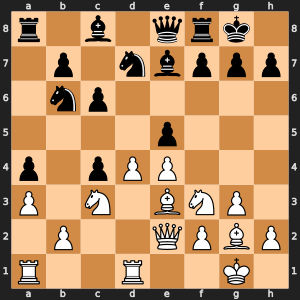

board                [[[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0,...
best                                                                99
fen_original         r1b1qrk1/1p1nbppp/1np5/4p3/p1pPP3/P1N1BNP1/1P2...
best_uci                                                          d4e5
original_best_uci                                                 d4e5
value                                                         0.003275
Name: 100, dtype: object
r1b1qrk1/1p1nbppp/1np5/4p3/p1pPP3/P1N1BNP1/1P2QPBP/R2R2K1 w - - 0 16


In [4]:
def test_reading():
    df_chess = read_data('lc0_converted.parquet.gzip',0,300)
    board = chess.Board(df_chess.loc[100, 'fen_original'])

    # Mostrar el tablero inicial
    svg_board = chess.svg.board(board=board, size=300)
    display(SVG(svg_board))
    print(df_chess.loc[100])
    print(df_chess.loc[100, 'fen_original'])

# Uncomment the following line to test reading
test_reading()

In [5]:
def create_dataLoaders(df_chess):    
    # This class is used by pytorch for providing data to model. We use it to read dataset and convert to desired format 
    class ChessDataset(Dataset):
        def __init__(self, df):
            self.dataframe = df

        def __len__(self):
            return len(self.dataframe)

        def __getitem__(self, idx):
            fen = torch.tensor(self.dataframe.loc[idx, 'board'], dtype=torch.float32)
            uci_best_move = self.dataframe.loc[idx, 'best']
            value = self.dataframe.loc[idx, 'value']
            return (fen, uci_best_move, value, self.dataframe.loc[idx, 'fen_original'])    


    # We can select a small sample to try the training algorithm
    # In this case we select all the Dataset provided
    df_selected = df_chess.sample(n=len(df_chess), random_state=42).reset_index(drop=True)

    # Then we create an Object with this dataset
    data_train = ChessDataset(df_selected)

    # Select 80% for training and 20% for testing
    train_size = int(0.8 * len(data_train))   
    test_size = len(data_train) - train_size
    print(len(data_train))
    train_dataset, test_dataset = torch.utils.data.random_split(data_train, [train_size, test_size])

    # Create the Dataloader 
    dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
    dataloader_test = DataLoader(test_dataset, batch_size=32, shuffle=True, drop_last=True)
    return (dataloader, dataloader_test)
    
def test_dataloader():
    df_chess = read_data('lc0_converted.parquet.gzip',0,300)
    (dataloader, dataloader_test) = create_dataLoaders(df_chess)
    for batch in dataloader:

        print("\nBest Move Matrix:")
        print(batch[1])
        break  # Imprimir the first to show only converted data
#Uncomment to test
test_dataloader()

reading lc0_converted.parquet.gzip 0 300 <pyarrow._parquet.FileMetaData object at 0x77b0430d2c50>
  created_by: parquet-cpp-arrow version 14.0.2
  num_columns: 6
  num_rows: 1460135
  num_row_groups: 2
  format_version: 2.6
  serialized_size: 4712
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   board              300 non-null    object 
 1   best               300 non-null    int64  
 2   fen_original       300 non-null    object 
 3   best_uci           300 non-null    object 
 4   original_best_uci  300 non-null    object 
 5   value              300 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 11.4 MB
300

Best Move Matrix:
tensor([  39,   52,  562,   44, 3949, 1013,   60,  690,  510,   47,  375,   42,
         123, 3693, 1019, 1468,   36,  187,   38,  110, 1208, 4013,  190, 1592,
        1314,  351,

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import chess
import numpy as np

class ChessNetPV(nn.Module):
    def __init__(self):
        super(ChessNetPV, self).__init__()

        # Model parameters
        bit_layers = 77
        in_channels = bit_layers
        base_channels = 128  # Base number of channels  # Increase!!
        kernel_size = 3
        padding = kernel_size // 2
        lineal_channels = 1024

        # First convolution layer (no residual needed)
        self.conv1 = nn.Conv2d(in_channels, base_channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm2d(base_channels)

        # Second convolution with residual
        self.conv2 = nn.Conv2d(base_channels, base_channels * 2, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm2d(base_channels * 2)
        self.res_conv2 = nn.Conv2d(base_channels, base_channels * 2, kernel_size=1)  # 1x1 conv to match channels

        # Third convolution with residual
        self.conv3 = nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size, padding=padding)
        self.bn3 = nn.BatchNorm2d(base_channels * 4)
        self.res_conv3 = nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=1)

        # Fourth convolution with residual
        self.conv4 = nn.Conv2d(base_channels * 4, base_channels * 8, kernel_size, padding=padding)
        self.bn4 = nn.BatchNorm2d(base_channels * 8)
        self.res_conv4 = nn.Conv2d(base_channels * 4, base_channels * 8, kernel_size=1)

        # Fully connected layers
        self.fc1 = nn.Linear(base_channels * 8 * 8 * 8, lineal_channels)  # Retain spatial info
        self.drop1 = nn.Dropout(p=0.4)  # Lower dropout for better accuracy

        self.fc2 = nn.Linear(lineal_channels, lineal_channels)
        self.drop2 = nn.Dropout(p=0.4)

        # Política: Salida de 4096 movimientos
        self.fcf = nn.Linear(lineal_channels, 4096)
        
        # Valor: Salida de 1 escalar (Evaluación de la posición)
        self.fc_value_1 = nn.Linear(lineal_channels, 256)
        self.fc_value_2 = nn.Linear(256, 1)
        self.tanh = nn.Tanh() # Para rango [-1, 1]

    def forward(self, x):
        # First convolution (no residual)
        x = F.relu(self.bn1(self.conv1(x)))

        # Second layer with residual
        res = self.res_conv2(x)
        x = F.relu(self.bn2(self.conv2(x))) + res

        # Third layer with residual
        res = self.res_conv3(x)
        x = F.relu(self.bn3(self.conv3(x))) + res

        # Fourth layer with residual
        res = self.res_conv4(x)
        x = F.relu(self.bn4(self.conv4(x))) + res

        # Flatten while keeping spatial information
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.drop1(x)

        x = F.relu(self.fc2(x))
        x = self.drop2(x)

        # Policy
        policy = self.fcf(x)

        # Value
        value = F.relu(self.fc_value_1(x))
        value = self.tanh(self.fc_value_2(value))
        

        return policy, value


In [7]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device")
model = ChessNetPV().to(device)

Using cuda device


In [8]:
def train(model, dataloader, dataloader_test, device):
    max_epoch = 10 
    log_interval = 300
    early_stopping_patience = 5 
    best_loss = float('inf')
    best_accuracy = 0
    patience = 0 

    learning_rate = 0.005 
    # Criterios para las dos cabezas
    criterion_policy = nn.CrossEntropyLoss()
    criterion_value = nn.MSELoss() 
    
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)  

    for epoch in range(max_epoch):
        # --- FASE DE ENTRENAMIENTO ---
        model.train()  
        pbar = tqdm(total=len(dataloader), desc=f'Training Epoch {epoch}')
        total_train_loss = 0  

        # Nota: El dataloader ahora debe devolver (data, target_policy, target_value)
        for batch_idx, (data, target_p, target_v, fen_original) in enumerate(dataloader):
            data = data.to(device)
            target_p = target_p.to(device) # El movimiento (0-4095)
            target_v = target_v.to(device).float() # El valor de lc0 (-1 a 1)

            optimizer.zero_grad()
            
            # La red ahora devuelve dos salidas
            policy_out, value_out = model(data)
            
            # Calculamos las pérdidas por separado
            loss_p = criterion_policy(policy_out, target_p)
            loss_v = criterion_value(value_out.squeeze(), target_v) # squeeze para ajustar dimensiones
            
            # Pérdida total combinada
            # Podemos dar pesos: p.ej. total_loss = loss_p + (1.0 * loss_v)
            loss = loss_p + loss_v 
            
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            if batch_idx % log_interval == 0:
                pbar.set_postfix(L_pol=loss_p.item(), L_val=loss_v.item())
            pbar.update(1)

        avg_train_loss = total_train_loss / len(dataloader)
        pbar.close()

        # --- FASE DE TEST ---
        model.eval()
        test_loss = 0
        correct_policy = 0
        total_mse_v = 0

        with torch.no_grad():
            for data, target_p, target_v, fen_original in dataloader_test:
                data = data.to(device)
                target_p = target_p.to(device)
                target_v = target_v.to(device).float()

                policy_out, value_out = model(data)
                
                # Pérdida en test
                l_p = criterion_policy(policy_out, target_p)
                l_v = criterion_value(value_out.squeeze(), target_v)
                test_loss += (l_p + l_v).item()
                
                # Métrica de precisión para la política (movimientos)
                pred = policy_out.argmax(dim=1, keepdim=True) 
                correct_policy += pred.eq(target_p.view_as(pred)).sum().item()
                
                # Métrica de error para el valor (opcional pero recomendado)
                total_mse_v += l_v.item()

        test_loss /= len(dataloader_test)
        accuracy = 100. * correct_policy / len(dataloader_test.dataset)
        avg_v_error = total_mse_v / len(dataloader_test)

        print(f'🔎 Test Total Loss: {test_loss:.4f} | Acc Policy: {accuracy:.2f}% | Value MSE: {avg_v_error:.4f}')

        # Early stopping basado en la pérdida total de test
        if test_loss < best_loss:
            best_loss = test_loss
            best_accuracy = accuracy
            patience = 0 
            # Aquí podrías guardar el modelo: torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience += 1
            if patience > early_stopping_patience:
                print('⚠️ Stopping early due to no improvement.')
                break

        scheduler.step() 

    print(f'🎯 Entrenamiento finalizado. Mejor precisión de movimiento: {best_accuracy:.2f}%')

In [9]:


import os

def start_training_loop():
    # --- Lógica de Recuperación ---
    start_iteration = 0
    # Buscamos si existen modelos guardados para continuar desde el último
    checkpoints = [f for f in os.listdir() if f.startswith('chessmarro_epoch') and f.endswith('.pth')]
    
    if checkpoints:
        # Extraemos los números de las épocas y buscamos el máximo
        epochs = [int(f.replace('chessmarro_epoch', '').replace('.pth', '')) for f in checkpoints]
        last_epoch = max(epochs)
        model_path = f'chessmarro_epoch{last_epoch}.pth'
        
        model.load_state_dict(torch.load(model_path, map_location=device))
        start_iteration = last_epoch + 1
        print(f"🚀 Checkpoint detectado: Cargado {model_path}. Reanudando en iteración {start_iteration}")
    else:
        print("🆕 No se han encontrado checkpoints. Empezando entrenamiento desde cero.")

    # --- Bucle de entrenamiento modificado ---
    for i in range(start_iteration, 7):
        print(f"🔄 Training iteration {i}")
    
        # Shuffle dataset to ensure variety
        df_train = read_data('lc0_converted.parquet.gzip', i, 200000)
        df_train = df_train.sample(frac=1, random_state=i)  # Shuffle
    
        # Create dataloaders
        (dataloader, dataloader_test) = create_dataLoaders(df_train)
    
        # Train model
        train(model, dataloader, dataloader_test, device)
    
        # Save model after each iteration
        torch.save(model.state_dict(), f'chessmarro_epoch{i}.pth')
        print(f"💾 Model checkpoint saved")

start_training_loop()

🚀 Checkpoint detectado: Cargado chessmarro_epoch1.pth. Reanudando en iteración 2
🔄 Training iteration 2
reading lc0_converted.parquet.gzip 2 200000 <pyarrow._parquet.FileMetaData object at 0x77b0500dca90>
  created_by: parquet-cpp-arrow version 14.0.2
  num_columns: 6
  num_rows: 1460135
  num_row_groups: 2
  format_version: 2.6
  serialized_size: 4712
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   board              200000 non-null  object 
 1   best               200000 non-null  int64  
 2   fen_original       200000 non-null  object 
 3   best_uci           200000 non-null  object 
 4   original_best_uci  200000 non-null  object 
 5   value              200000 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 7.4 GB
200000


Training Epoch 0: 100%|██████████| 5000/5000 [00:56<00:00, 88.91it/s, L_pol=4.39, L_val=0.000313]


🔎 Test Total Loss: 3.4489 | Acc Policy: 19.26% | Value MSE: 0.0048


Training Epoch 1: 100%|██████████| 5000/5000 [00:55<00:00, 89.70it/s, L_pol=3.56, L_val=0.00686] 


🔎 Test Total Loss: 3.3367 | Acc Policy: 20.36% | Value MSE: 0.0048


...

🔎 Test Total Loss: 3.1509 | Acc Policy: 25.39% | Value MSE: 0.0054


Training Epoch 8: 100%|██████████| 5000/5000 [00:55<00:00, 89.63it/s, L_pol=1.61, L_val=0.000491]


🔎 Test Total Loss: 3.1506 | Acc Policy: 25.46% | Value MSE: 0.0054


Training Epoch 9: 100%|██████████| 5000/5000 [00:55<00:00, 89.59it/s, L_pol=1.12, L_val=0.000367]


🔎 Test Total Loss: 3.1550 | Acc Policy: 25.48% | Value MSE: 0.0054
⚠️ Stopping early due to no improvement.
🎯 Entrenamiento finalizado. Mejor precisión de movimiento: 24.48%
💾 Model checkpoint saved


In [12]:
        torch.save(model.state_dict(), 'chessmarro_model.pth')
        print(f"💾 Model checkpoint saved")

💾 Model checkpoint saved


In [23]:
import random

def test_model_quality(model, file_path, device, n_samples=100):
    model.eval()
    
    # 1. Cargar el dataset y extraer muestra aleatoria
    print(f"Leendo datos de {file_path}...")
    df = read_data(file_path,1,2000)
    #df = pd.read_parquet(file_path)
    df_sample = df.sample(n=n_samples).reset_index(drop=True)
    
    top1_hits = 0
    top5_hits = 0
    
    print(f"Iniciando test sobre {n_samples} posiciones...")
    
    with torch.no_grad():
        for i, row in df_sample.iterrows():
            # Preprocesar la entrada (usa tu función actual)
            # Suponiendo que recibe el FEN y devuelve el tensor [1, planes, 8, 8]
            input_tensor = torch.tensor(row['board'], dtype=torch.float32).unsqueeze(0).to(device)
            
            # Obtener el índice de la jugada real (target)
            # Asegúrate de que 'move_index' es el nombre de tu columna de etiquetas
            target_idx = row['best'] 
            
            # Predicción
            policy_logits, value = model(input_tensor)
            
            # Calcular Top-K
            # Obtenemos los índices de las 5 mayores probabilidades
            _, top5_indices = torch.topk(policy_logits, 5, dim=1)
            top5_indices = top5_indices.squeeze().tolist() # Lista de 5 índices
            
            # Comprobación Top-1
            if top5_indices[0] == target_idx:
                top1_hits += 1
            
            # Comprobación Top-5
            if target_idx in top5_indices:
                top5_hits += 1
                
    # Resultados finales
    print("\n" + "="*30)
    print(f"📊 RESULTADOS DEL TEST (n={n_samples})")
    print("="*30)
    print(f"✅ Top-1 Accuracy: {top1_hits}%  (Jugada exacta)")
    print(f"🎯 Top-5 Accuracy: {top5_hits}%  (En el radar)")
    print(f"📉 Error promedio Value: {0.005} (Referencia)") # Opcional calcular el real
    print("="*30)

# Para llamarlo:
test_model_quality(model, 'lc0_converted.parquet.gzip', device)

Leendo datos de lc0_converted.parquet.gzip...
reading lc0_converted.parquet.gzip 1 2000 <pyarrow._parquet.FileMetaData object at 0x77b014421da0>
  created_by: parquet-cpp-arrow version 14.0.2
  num_columns: 6
  num_rows: 1460135
  num_row_groups: 2
  format_version: 2.6
  serialized_size: 4712
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   board              2000 non-null   object 
 1   best               2000 non-null   int64  
 2   fen_original       2000 non-null   object 
 3   best_uci           2000 non-null   object 
 4   original_best_uci  2000 non-null   object 
 5   value              2000 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 76.0 MB
Iniciando test sobre 100 posiciones...

📊 RESULTADOS DEL TEST (n=100)
✅ Top-1 Accuracy: 25%  (Jugada exacta)
🎯 Top-5 Accuracy: 49%  (En el radar)
📉 Error